# Data loading & preprocessing

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('customer_support_tickets.csv')
print(df.shape)
print(df.isnull().sum())

# Satisfaction rating only in closed tickets
df_closed = df[df['Ticket Status'] == 'Closed'].copy()
print(f"Closed tickets: {len(df_closed)}")

# ✅ Convert date columns FIRST
df_closed['Date of Purchase'] = pd.to_datetime(
    df_closed['Date of Purchase'], dayfirst=True, errors='coerce'
)

df_closed['First Response Time'] = pd.to_datetime(
    df_closed['First Response Time'], dayfirst=True, errors='coerce'
)

df_closed['Time to Resolution'] = pd.to_datetime(
    df_closed['Time to Resolution'], dayfirst=True, errors='coerce'
)

# ✅ Response time in hours
df_closed['response_hours'] = (
    df_closed['First Response Time'] - df_closed['Date of Purchase']
).dt.total_seconds() / 3600

# ✅ Resolution time in hours
df_closed['resolution_hours'] = (
    df_closed['Time to Resolution'] - df_closed['First Response Time']
).dt.total_seconds() / 3600

# Replace infinite values
df_closed.replace([np.inf, -np.inf], np.nan, inplace=True)
df_closed.fillna(df_closed.median(numeric_only=True), inplace=True)

(8469, 17)
Ticket ID                          0
Customer Name                      0
Customer Email                     0
Customer Age                       0
Customer Gender                    0
Product Purchased                  0
Date of Purchase                   0
Ticket Type                        0
Ticket Subject                     0
Ticket Description                 0
Ticket Status                      0
Resolution                      5700
Ticket Priority                    0
Ticket Channel                     0
First Response Time             2819
Time to Resolution              5700
Customer Satisfaction Rating    5700
dtype: int64
Closed tickets: 2769


# EDA (Exploratory Data Analysis)

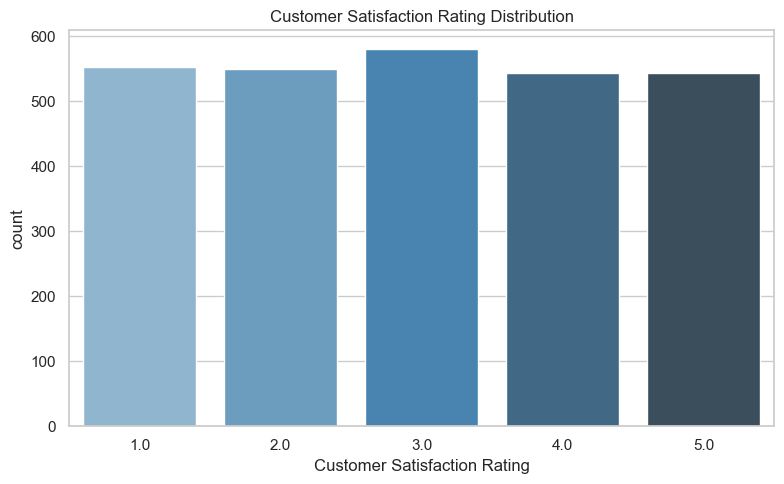

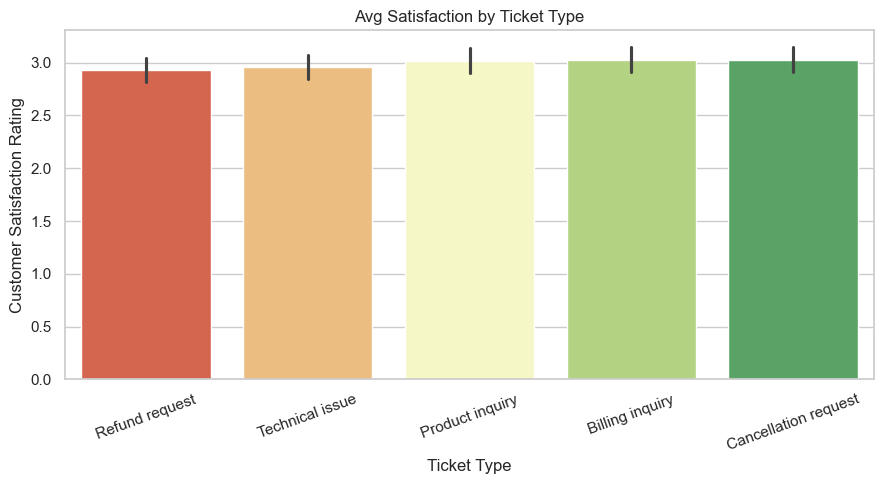

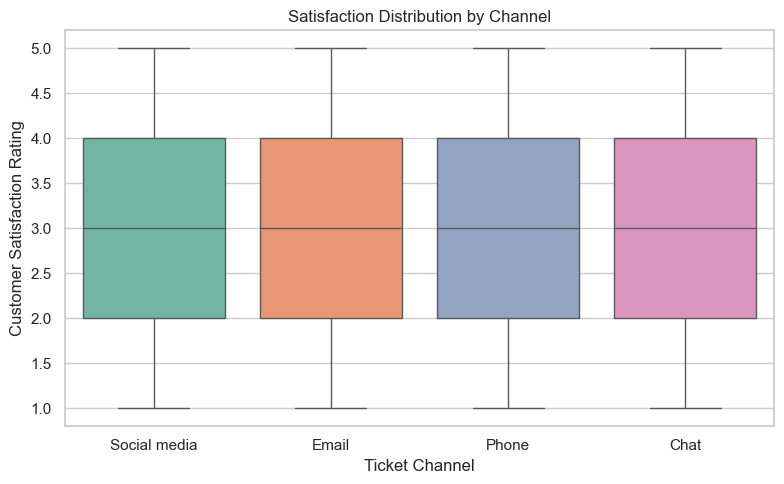

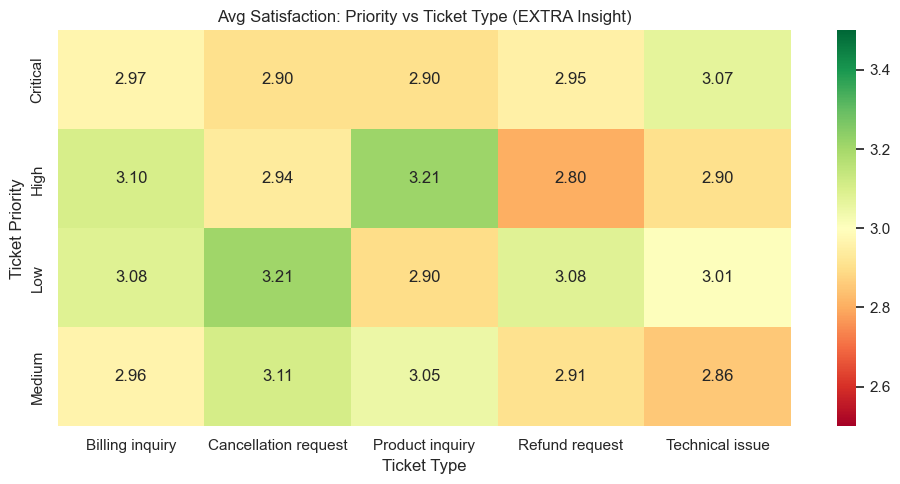

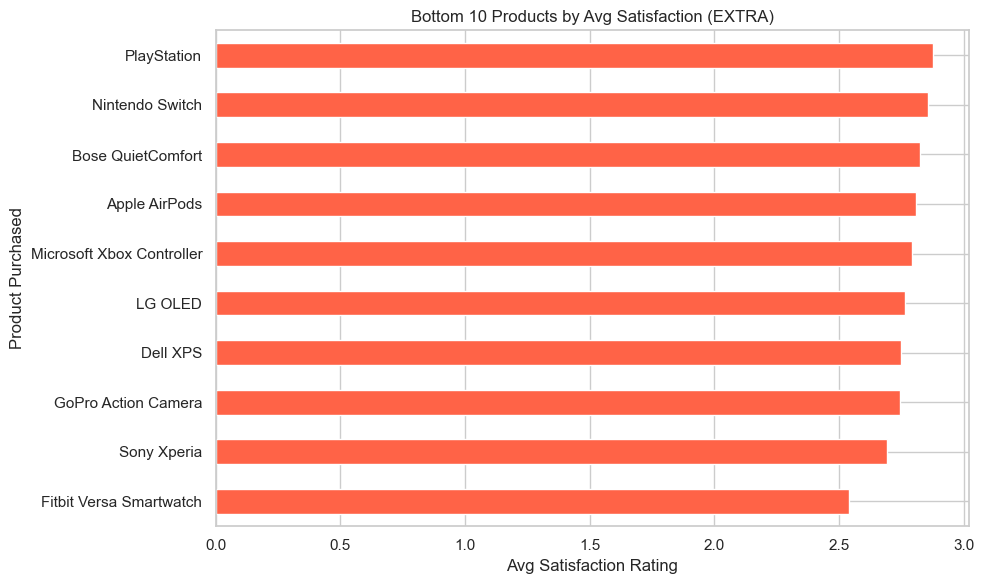

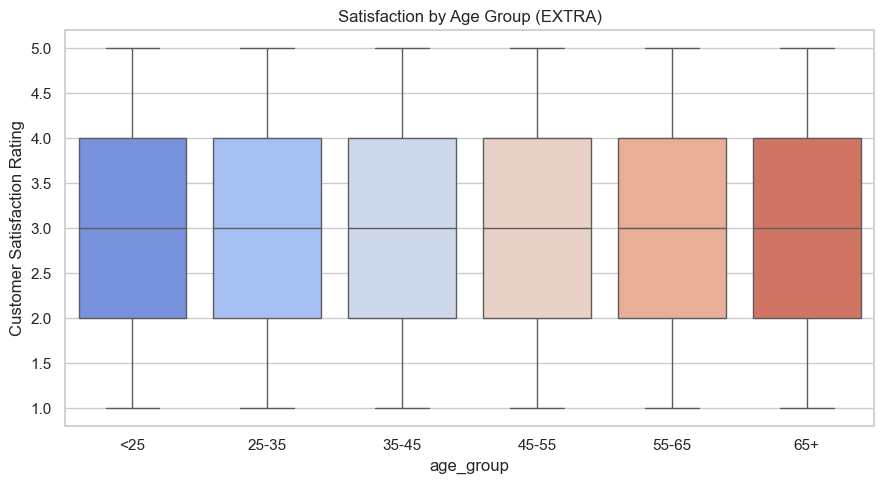

In [8]:
sns.set(style='whitegrid')

# 1. Satisfaction Distribution
plt.figure(figsize=(8,5))
sns.countplot(x='Customer Satisfaction Rating', data=df_closed, palette='Blues_d')
plt.title('Customer Satisfaction Rating Distribution')
plt.tight_layout(); plt.show()

# 2. Avg satisfaction by Ticket Type
plt.figure(figsize=(9,5))
order = df_closed.groupby('Ticket Type')['Customer Satisfaction Rating'].mean().sort_values().index
sns.barplot(x='Ticket Type', y='Customer Satisfaction Rating',
            data=df_closed, order=order, palette='RdYlGn')
plt.title('Avg Satisfaction by Ticket Type')
plt.xticks(rotation=20); plt.tight_layout(); plt.show()

# 3. Ticket Channel vs Satisfaction
plt.figure(figsize=(8,5))
sns.boxplot(x='Ticket Channel', y='Customer Satisfaction Rating',
            data=df_closed, palette='Set2')
plt.title('Satisfaction Distribution by Channel')
plt.tight_layout(); plt.show()

# 4. Heatmap: Priority x Ticket Type avg satisfaction
pivot = df_closed.pivot_table(
    values='Customer Satisfaction Rating',
    index='Ticket Priority', columns='Ticket Type', aggfunc='mean'
)
plt.figure(figsize=(10,5))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn', vmin=2.5, vmax=3.5)
plt.title('Avg Satisfaction: Priority vs Ticket Type (EXTRA Insight)')
plt.tight_layout(); plt.show()

# 5. Products with worst satisfaction
prod_sat = df_closed.groupby('Product Purchased')['Customer Satisfaction Rating'].mean().sort_values()
plt.figure(figsize=(10,6))
prod_sat.head(10).plot(kind='barh', color='tomato')
plt.title('Bottom 10 Products by Avg Satisfaction (EXTRA)')
plt.xlabel('Avg Satisfaction Rating')
plt.tight_layout(); plt.show()

# 6. Age group vs satisfaction
bins = [0,25,35,45,55,65,100]
labels = ['<25','25-35','35-45','45-55','55-65','65+']
df_closed['age_group'] = pd.cut(df_closed['Customer Age'], bins=bins, labels=labels)
plt.figure(figsize=(9,5))
sns.boxplot(x='age_group', y='Customer Satisfaction Rating',
            data=df_closed, palette='coolwarm')
plt.title('Satisfaction by Age Group (EXTRA)')
plt.tight_layout(); plt.show()

#  Feature Engineering

In [6]:
# Satisfaction in binary format: 1=satisfied (4-5), 0=not satisfied (1-3)
df_closed['satisfaction_binary'] = (df_closed['Customer Satisfaction Rating'] >= 4).astype(int)
print(df_closed['satisfaction_binary'].value_counts())

# Categorical columns encoded
le = LabelEncoder()
cat_cols = ['Customer Gender', 'Product Purchased', 'Ticket Type',
            'Ticket Subject', 'Ticket Priority', 'Ticket Channel']

df_encoded = df_closed.copy()
for col in cat_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

# Make feature by using keywords in tickets (NLP-lite)
df_encoded['subject_is_refund'] = df_closed['Ticket Subject'].str.contains(
    'refund|cancel', case=False).astype(int)
df_encoded['subject_is_technical'] = df_closed['Ticket Subject'].str.contains(
    'bug|network|hardware|setup', case=False).astype(int)

# Age groups encoded
df_encoded['age_group_enc'] = le.fit_transform(df_closed['age_group'].astype(str))

# Features select
features = ['Customer Age', 'Customer Gender', 'Product Purchased',
            'Ticket Type', 'Ticket Priority', 'Ticket Channel',
            'response_hours', 'resolution_hours',
            'subject_is_refund', 'subject_is_technical', 'age_group_enc']

X = df_encoded[features].fillna(0)
y = df_encoded['satisfaction_binary']

print(f"Feature shape: {X.shape}")
print(f"Satisfied: {y.sum()} | Not satisfied: {(y==0).sum()}")

satisfaction_binary
0    1682
1    1087
Name: count, dtype: int64
Feature shape: (2769, 11)
Satisfied: 1087 | Not satisfied: 1682


# Model Building (3 models)

In [9]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, roc_auc_score, roc_curve)
import xgboost as xgb

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# Model 1: Logistic Regression
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_sc, y_train)
lr_pred = lr.predict(X_test_sc)
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, lr_pred):.2%}")

# Model 2: Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print(f"Random Forest Accuracy: {accuracy_score(y_test, rf_pred):.2%}")

# Model 3: XGBoost
xgb_model = xgb.XGBClassifier(n_estimators=200, random_state=42,
                                use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
print(f"XGBoost Accuracy: {accuracy_score(y_test, xgb_pred):.2%}")

Logistic Regression Accuracy: 60.83%
Random Forest Accuracy: 57.22%
XGBoost Accuracy: 52.35%


# Evaluation & Visualization

               precision    recall  f1-score   support

Not Satisfied       0.61      0.85      0.71       337
    Satisfied       0.38      0.15      0.21       217

     accuracy                           0.57       554
    macro avg       0.49      0.50      0.46       554
 weighted avg       0.52      0.57      0.51       554



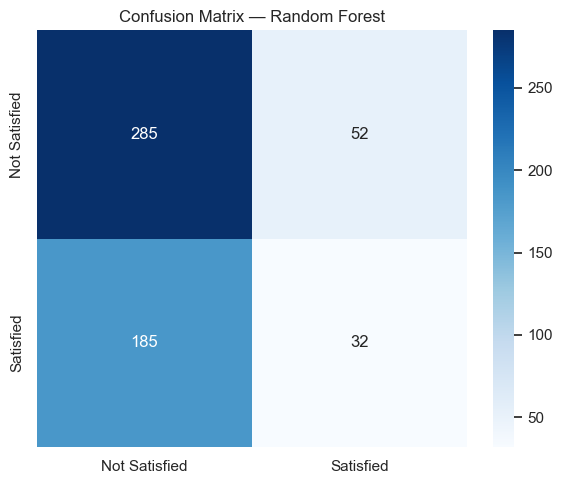

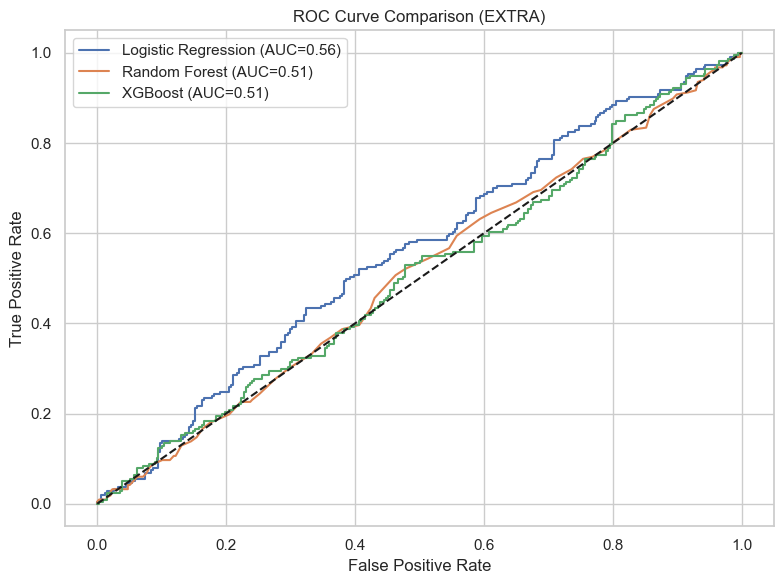

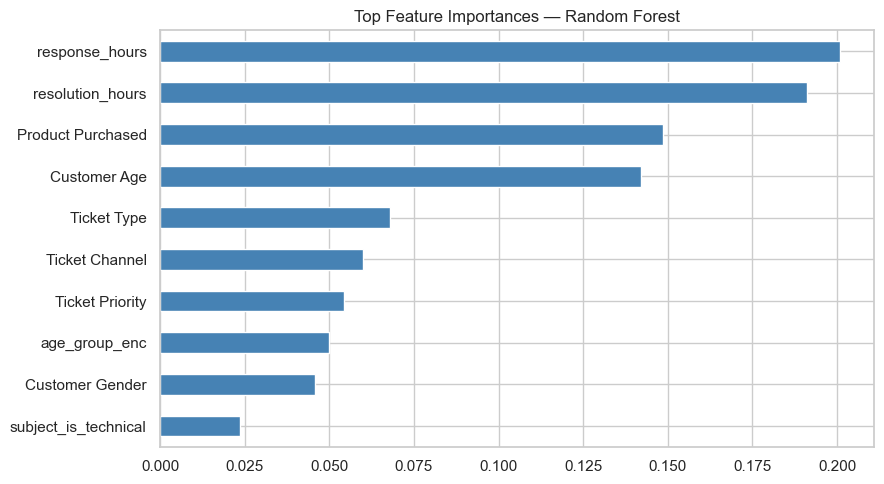

In [10]:
# Full report for best model
print(classification_report(y_test, rf_pred,
      target_names=['Not Satisfied','Satisfied']))

# Confusion Matrix
plt.figure(figsize=(6,5))
cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Satisfied','Satisfied'],
            yticklabels=['Not Satisfied','Satisfied'])
plt.title('Confusion Matrix — Random Forest')
plt.tight_layout(); plt.show()

# ROC Curve
plt.figure(figsize=(8,6))
for name, model, X_t, proba in [
    ('Logistic Regression', lr, X_test_sc, lr.predict_proba(X_test_sc)[:,1]),
    ('Random Forest', rf, X_test, rf.predict_proba(X_test)[:,1]),
    ('XGBoost', xgb_model, X_test, xgb_model.predict_proba(X_test)[:,1])
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.2f})')
plt.plot([0,1],[0,1],'k--')
plt.title('ROC Curve Comparison (EXTRA)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(); plt.tight_layout(); plt.show()

# Feature Importance
feat_imp = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)
feat_imp.tail(10).plot(kind='barh', figsize=(9,5), color='steelblue')
plt.title('Top Feature Importances — Random Forest')
plt.tight_layout(); plt.show()

# Product Quality Alert System

In [11]:
# Product alert
low_sat_products = df_closed.groupby('Product Purchased')['Customer Satisfaction Rating'].mean()
alerts = low_sat_products[low_sat_products < 2.7]
print("Products needing immediate attention:")
print(alerts.sort_values())

Products needing immediate attention:
Product Purchased
Fitbit Versa Smartwatch    2.539683
Sony Xperia                2.692308
Name: Customer Satisfaction Rating, dtype: float64


# NLP Sentiment on Ticket Description

In [12]:
!pip install textblob

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------- ----------------------- 262.1/625.0 kB ? eta -:--:--
   ---------------------------------------- 625.0/625.0 kB 1.4 MB/s  0:00:00


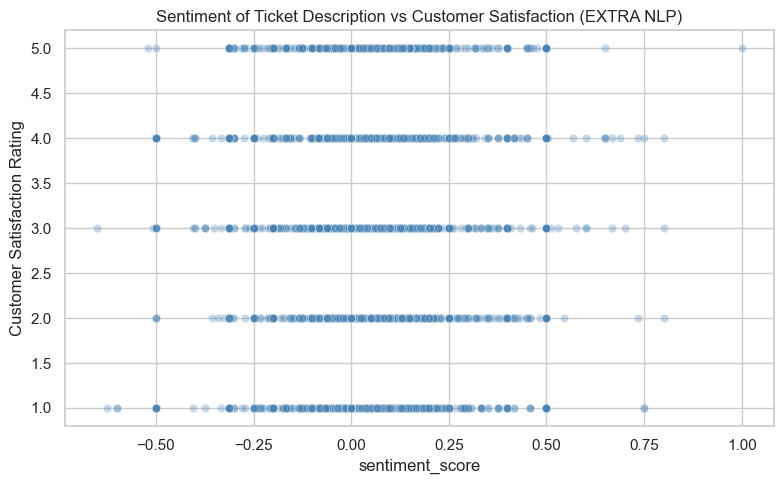

In [13]:
# Sentiment Analysis
from textblob import TextBlob

df_closed['sentiment_score'] = df_closed['Ticket Description'].apply(
    lambda x: TextBlob(str(x)).sentiment.polarity
)
plt.figure(figsize=(8,5))
sns.scatterplot(x='sentiment_score', y='Customer Satisfaction Rating',
                data=df_closed, alpha=0.3, color='steelblue')
plt.title('Sentiment of Ticket Description vs Customer Satisfaction (EXTRA NLP)')
plt.tight_layout(); plt.show()

# Resolution Time Impact Analysis

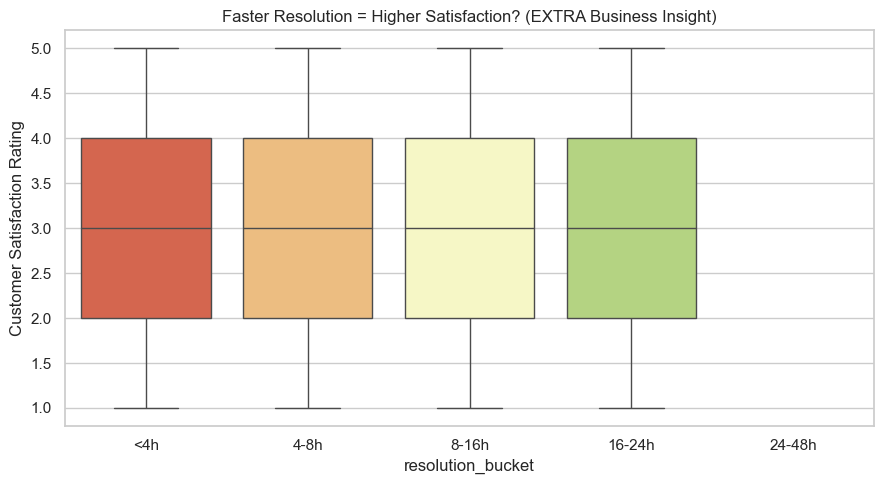

In [14]:
# Resolution time bins
df_closed['resolution_bucket'] = pd.cut(
    df_closed['resolution_hours'].clip(0, 48),
    bins=[0,4,8,16,24,48], labels=['<4h','4-8h','8-16h','16-24h','24-48h']
)
plt.figure(figsize=(9,5))
sns.boxplot(x='resolution_bucket', y='Customer Satisfaction Rating',
            data=df_closed, palette='RdYlGn')
plt.title('Faster Resolution = Higher Satisfaction? (EXTRA Business Insight)')
plt.tight_layout(); plt.show()